In [1]:
import os
import numpy as np

# =========================
# 0) CONFIG F2 (Week 04)
# =========================

# Prefer repo paths; fall back to the uploaded paths if not found
INPUTS_PATH = "data/F2/initial_inputs.npy"
OUTPUTS_PATH = "data/F2/initial_outputs.npy"

if not os.path.exists(INPUTS_PATH):
    INPUTS_PATH = "/mnt/data/initial_inputs.npy"
if not os.path.exists(OUTPUTS_PATH):
    OUTPUTS_PATH = "/mnt/data/initial_outputs.npy"

# F2 search space
BOUNDS = np.array([
    [0.0, 1.0],  # x1
    [0.0, 1.0],  # x2
], dtype=float)

MAXIMIZE = True  # F2: maximize log-likelihood score (as per description)

# Acquisition (EI)
XI = 0.03  # exploration parameter (keep slightly >0 due to noise)

# Candidate generation
N_CAND_GLOBAL = 30000
N_CAND_LOCAL  = 20000
LOCAL_SIGMA   = 0.08   # local sampling radius around current best

# Diversity constraint (avoid picking almost-duplicate points)
MIN_DIST = 0.03

# Reproducibility
RANDOM_SEED = 7

# Output requirement (week 04): ONE row only
BATCH_SIZE = 1

In [2]:
# =========================
# 1) LOAD DATA
# =========================
X = np.load(INPUTS_PATH)
y = np.load(OUTPUTS_PATH)

# Basic cleanup
X = np.asarray(X, dtype=float)
y = np.asarray(y, dtype=float).reshape(-1)

print("Loaded:")
print("  X shape:", X.shape)
print("  y shape:", y.shape)
print("  y min/max:", float(y.min()), float(y.max()))
print("  last X:", X[-1:])
print("  last y:", y[-1:])

# Sanity: ensure within bounds (allow tiny numeric tolerance)
tol = 1e-9
if np.any(X < (BOUNDS[:, 0] - tol)) or np.any(X > (BOUNDS[:, 1] + tol)):
    print("\n[WARN] Some X are outside [0,1] bounds (check data).")

Loaded:
  X shape: (12, 2)
  y shape: (12,)
  y min/max: -0.06729793513055146 0.6112052157614438
  last X: [[0.3125 1.    ]]
  last y: [-0.06729794]


In [3]:
# =========================
# 2) SURROGATE MODELS
# =========================
import warnings
warnings.filterwarnings("ignore")

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Standardize y for GP numerical stability (we un-standardize predictions later)
y_mean = float(y.mean())
y_std  = float(y.std()) if float(y.std()) > 1e-12 else 1.0
y_z = (y - y_mean) / y_std

# --- GP ---
kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-2, 1e2), nu=2.5)
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e-1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=False,
    n_restarts_optimizer=10,
    random_state=RANDOM_SEED
)
gp.fit(X, y_z)

def gp_predict(Xq):
    """Return GP mean/std in ORIGINAL y scale."""
    mu_z, std_z = gp.predict(Xq, return_std=True)
    mu = mu_z * y_std + y_mean
    std = std_z * y_std
    return mu, std

print("GP kernel (fitted):", gp.kernel_)

# --- RF ensemble (uncertainty via disagreement) ---
N_RF = 10
rf_ens = []
for i in range(N_RF):
    rf = RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=1,
        random_state=RANDOM_SEED + i,
        n_jobs=-1
    )
    rf.fit(X, y)
    rf_ens.append(rf)

def ens_predict(models, Xq):
    """Return mean/std across ensemble members."""
    preds = np.vstack([m.predict(Xq) for m in models])  # [n_models, n_points]
    return preds.mean(axis=0), preds.std(axis=0)

# --- GBM ensemble ---
N_GBM = 10
gbm_ens = []
for i in range(N_GBM):
    gbm = GradientBoostingRegressor(
        random_state=RANDOM_SEED + 100 + i,
        n_estimators=400,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9
    )
    gbm.fit(X, y)
    gbm_ens.append(gbm)

print(f"Trained RF ensemble:  {len(rf_ens)} models")
print(f"Trained GBM ensemble: {len(gbm_ens)} models")

GP kernel (fitted): 1**2 * Matern(length_scale=[0.081, 100], nu=2.5) + WhiteKernel(noise_level=0.0105)
Trained RF ensemble:  10 models
Trained GBM ensemble: 10 models


In [4]:
# =========================
# 3) ACQUISITION: Expected Improvement (EI)
# =========================
from scipy.stats import norm

rng = np.random.default_rng(RANDOM_SEED)

best_idx = int(np.argmax(y)) if MAXIMIZE else int(np.argmin(y))
x_best = X[best_idx]
y_best = float(y[best_idx])

def expected_improvement(Xcand, y_best, xi=0.01):
    """
    EI for maximization using GP posterior.
    """
    mu, sigma = gp_predict(Xcand)
    sigma = np.maximum(sigma, 1e-12)

    imp = mu - y_best - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma < 1e-12] = 0.0
    return ei, mu, sigma

# Candidate set: global + local
Xg = rng.uniform(BOUNDS[:, 0], BOUNDS[:, 1], size=(N_CAND_GLOBAL, 2))

Xl = x_best + rng.normal(0.0, LOCAL_SIGMA, size=(N_CAND_LOCAL, 2))
Xl = np.clip(Xl, BOUNDS[:, 0], BOUNDS[:, 1])

Xcand = np.vstack([Xg, Xl])

ei, mu_c, sig_c = expected_improvement(Xcand, y_best=y_best, xi=XI)

# Sort by EI descending and pick first that satisfies MIN_DIST to existing points
order = np.argsort(-ei)

def min_dist_to_existing(x):
    return float(np.min(np.linalg.norm(X - x, axis=1)))

x_next = None
for idx in order[:5000]:  # search top candidates first (fast)
    x_try = Xcand[idx]
    if min_dist_to_existing(x_try) >= MIN_DIST:
        x_next = x_try
        break

# If constraint too strict, relax gracefully
if x_next is None:
    print("[WARN] No candidate met MIN_DIST; relaxing constraint.")
    x_next = Xcand[order[0]]

print("Current best observed:")
print("  x_best:", x_best)
print("  y_best:", y_best)

# Report the chosen point stats
ei_best = float(ei[order[0]])
md = min_dist_to_existing(x_next)
mu_next, std_next = gp_predict(x_next.reshape(1, -1))
print("\nChosen next x (by EI + diversity):")
print("  x_next:", x_next)
print("  min_dist_to_existing:", md)
print("  GP mu/std at x_next:", float(mu_next[0]), float(std_next[0]))

Current best observed:
  x_best: [0.70263656 0.9265642 ]
  y_best: 0.6112052157614438

Chosen next x (by EI + diversity):
  x_next: [0.96820794 0.68992715]
  min_dist_to_existing: 0.12474594593648644
  GP mu/std at x_next: 0.3733756066105106 0.20348517582062786


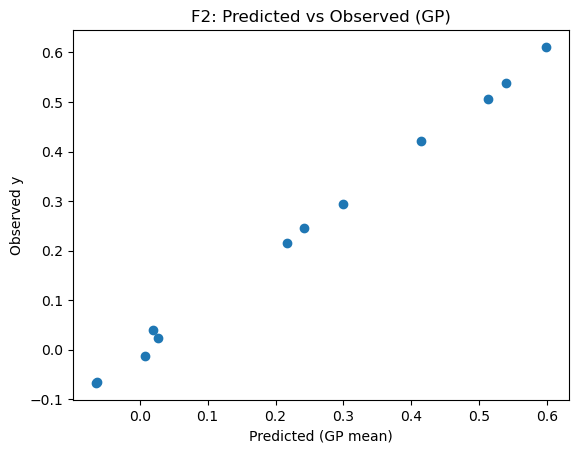

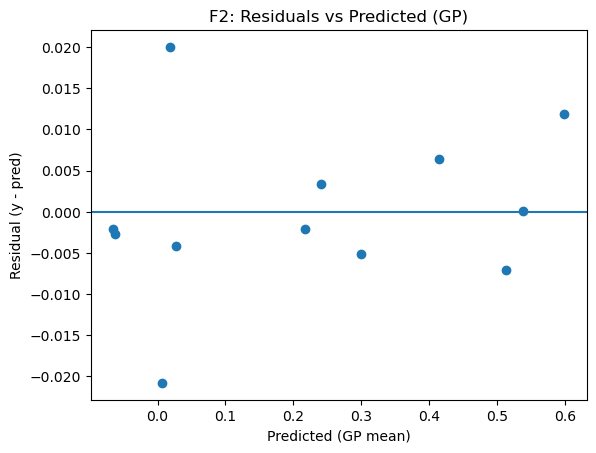

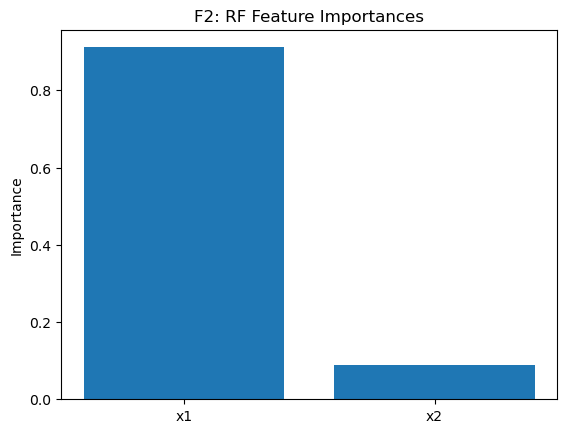

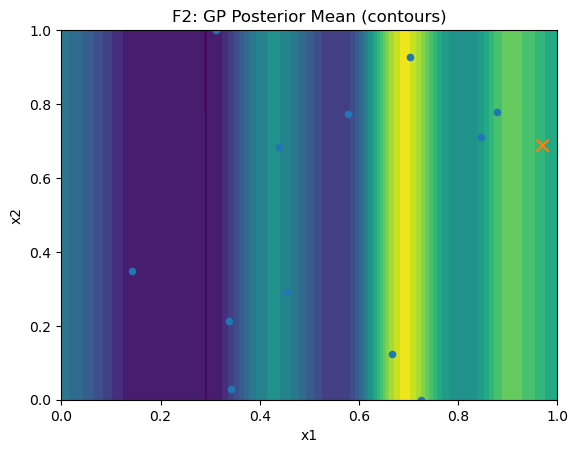

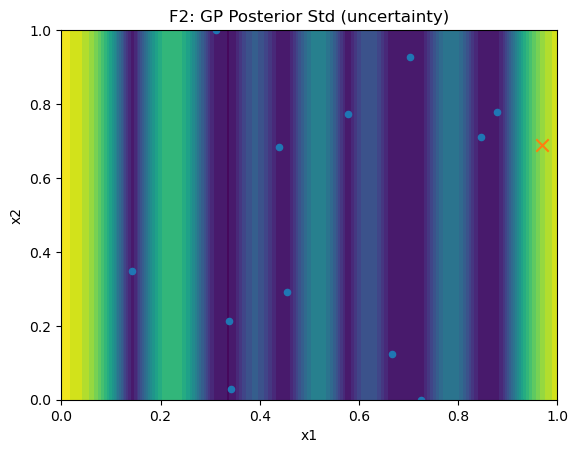


Uncertainty comparison at x_next:
  GP  mean/std: 0.3733756066105106 0.20348517582062786
  RF  mean/std: 0.37528403310386904 0.0037455161286551525
  GBM mean/std: 0.35385671216809683 0.011969852449855555


In [5]:
# =========================
# 4) DIAGNOSTICS
# =========================
import matplotlib.pyplot as plt

# --- Predicted vs Observed (GP, in-sample) ---
mu_train, std_train = gp_predict(X)
resid = y - mu_train

plt.figure()
plt.scatter(mu_train, y)
plt.xlabel("Predicted (GP mean)")
plt.ylabel("Observed y")
plt.title("F2: Predicted vs Observed (GP)")
plt.show()

# --- Residuals ---
plt.figure()
plt.scatter(mu_train, resid)
plt.axhline(0.0)
plt.xlabel("Predicted (GP mean)")
plt.ylabel("Residual (y - pred)")
plt.title("F2: Residuals vs Predicted (GP)")
plt.show()

# --- Feature importance (RF) ---
# Use the first RF model for a stable ranking (or average across ensemble)
fi = rf_ens[0].feature_importances_
plt.figure()
plt.bar([0, 1], fi)
plt.xticks([0, 1], ["x1", "x2"])
plt.ylabel("Importance")
plt.title("F2: RF Feature Importances")
plt.show()

# --- 2D mean/uncertainty contour maps (GP) ---
grid_n = 120
x1 = np.linspace(BOUNDS[0, 0], BOUNDS[0, 1], grid_n)
x2 = np.linspace(BOUNDS[1, 0], BOUNDS[1, 1], grid_n)
X1, X2 = np.meshgrid(x1, x2)
Xgrid = np.column_stack([X1.ravel(), X2.ravel()])

mu_grid, std_grid = gp_predict(Xgrid)
MU = mu_grid.reshape(grid_n, grid_n)
STD = std_grid.reshape(grid_n, grid_n)

plt.figure()
plt.contourf(X1, X2, MU, levels=20)
plt.scatter(X[:, 0], X[:, 1], s=20)
plt.scatter([x_next[0]], [x_next[1]], s=80, marker="x")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("F2: GP Posterior Mean (contours)")
plt.show()

plt.figure()
plt.contourf(X1, X2, STD, levels=20)
plt.scatter(X[:, 0], X[:, 1], s=20)
plt.scatter([x_next[0]], [x_next[1]], s=80, marker="x")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("F2: GP Posterior Std (uncertainty)")
plt.show()

# --- Optional: compare uncertainty proxies at x_next ---
rf_mu, rf_std = ens_predict(rf_ens, x_next.reshape(1, -1))
gbm_mu, gbm_std = ens_predict(gbm_ens, x_next.reshape(1, -1))

print("\nUncertainty comparison at x_next:")
print("  GP  mean/std:", float(mu_next[0]), float(std_next[0]))
print("  RF  mean/std:", float(rf_mu[0]), float(rf_std[0]))
print("  GBM mean/std:", float(gbm_mu[0]), float(gbm_std[0]))

In [6]:
# =========================
# 5) OUTPUT: ONE ROW TO SUBMIT (Week 04)
# =========================
x_submit = x_next.copy()

print("=== RECOMMENDED NEXT X (submit this 1 row) ===")
print(x_submit)
print("Rounded (6 dp):", np.round(x_submit, 6))
print("Shape:", x_submit.shape)

=== RECOMMENDED NEXT X (submit this 1 row) ===
[0.96820794 0.68992715]
Rounded (6 dp): [0.968208 0.689927]
Shape: (2,)
